In [2]:
!pip3 install sentence-transformers
!pip3 install seaborn
!pip3 install scikit-learn
!pip3 install matplotlib
print('All libraries installed!')


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Precision\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Precision\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Precision\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


All libraries installed!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Precision\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print('Libraries imported!')

C:\Users\Precision\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported!


In [4]:
sentences = [
    # Cricket (4 sentences)
    'The batsman hit a six off the last ball to win the match.',
    'India won the test series after an amazing final day.',
    'The fast bowler took three wickets in a single over.',
    'The fielder took a brilliant catch near the boundary.',
    # Cooking (3 sentences)
    'Fry the onions in oil until they turn golden brown.',
    'Add salt to the dough and let it rest for one hour.',
    'The recipe needs fresh tomatoes and basil leaves.',
    # Cybersecurity (3 sentences)
    'The hacker broke into the website using a fake login page.',
    'Always use two step verification to keep your account safe.',
    'Update your software regularly to fix security problems.'
]

topics = [
    'Cricket','Cricket','Cricket','Cricket',
    'Cooking','Cooking','Cooking',
    'Cybersecurity','Cybersecurity','Cybersecurity'
]

print('Total sentences:', len(sentences))
print()
for i in range(len(sentences)):
    print(str(i+1) + '. [' + topics[i] + '] ' + sentences[i])

Total sentences: 10

1. [Cricket] The batsman hit a six off the last ball to win the match.
2. [Cricket] India won the test series after an amazing final day.
3. [Cricket] The fast bowler took three wickets in a single over.
4. [Cricket] The fielder took a brilliant catch near the boundary.
5. [Cooking] Fry the onions in oil until they turn golden brown.
6. [Cooking] Add salt to the dough and let it rest for one hour.
7. [Cooking] The recipe needs fresh tomatoes and basil leaves.
8. [Cybersecurity] The hacker broke into the website using a fake login page.
9. [Cybersecurity] Always use two step verification to keep your account safe.
10. [Cybersecurity] Update your software regularly to fix security problems.


In [5]:
print('Loading model: all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded!')

embeddings = model.encode(sentences)
print('Embeddings created!')
print('Shape:', embeddings.shape)
print('10 sentences x 384 numbers each')

Loading model: all-MiniLM-L6-v2 ...


C:\Users\Precision\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Precision\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
L

Model loaded!
Embeddings created!
Shape: (10, 384)
10 sentences x 384 numbers each


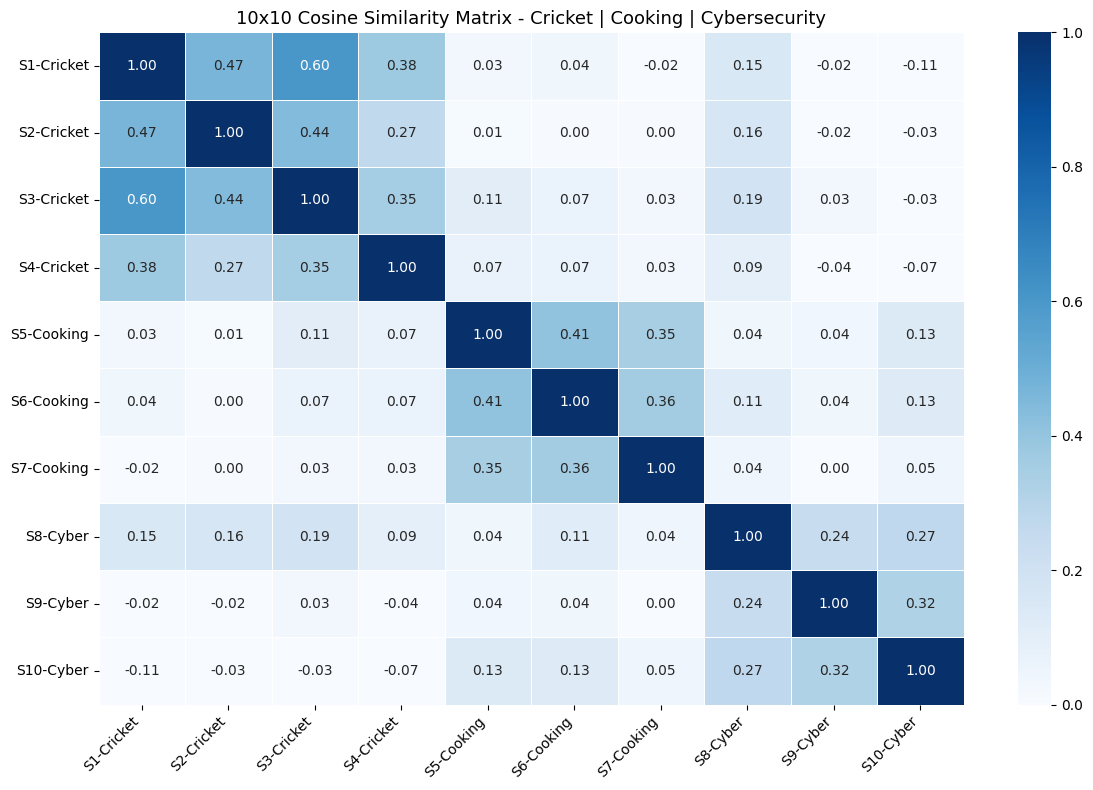


Cricket S1-S4 = dark blue with each other
Cooking S5-S7 = dark blue with each other
Cyber S8-S10  = dark blue with each other
Different topics = light blue = low similarity


In [6]:
similarity_matrix = cosine_similarity(embeddings)

labels = [
    'S1-Cricket','S2-Cricket','S3-Cricket','S4-Cricket',
    'S5-Cooking','S6-Cooking','S7-Cooking',
    'S8-Cyber','S9-Cyber','S10-Cyber'
]

plt.figure(figsize=(12, 8))
sns.heatmap(
    similarity_matrix,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, vmin=0, vmax=1
)
plt.title('10x10 Cosine Similarity Matrix - Cricket | Cooking | Cybersecurity', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print()
print('Cricket S1-S4 = dark blue with each other')
print('Cooking S5-S7 = dark blue with each other')
print('Cyber S8-S10  = dark blue with each other')
print('Different topics = light blue = low similarity')

In [7]:
query = 'The bowler took three wickets in one over'

print('Query sentence:', query)
print('-' * 55)

query_embedding = model.encode([query])
scores = cosine_similarity(query_embedding, embeddings)[0]
top2 = np.argsort(scores)[::-1][:2]

print()
print('Top 2 Most Similar Sentences:')
print()
for rank in range(2):
    index = top2[rank]
    print('Rank', rank + 1)
    print('Sentence :', sentences[index])
    print('Topic    :', topics[index])
    print('Score    :', round(scores[index], 4))
    print()

print('The query is about cricket so Cricket sentences are most similar!')
print('The model understands MEANING not just keywords!')

Query sentence: The bowler took three wickets in one over
-------------------------------------------------------

Top 2 Most Similar Sentences:

Rank 1
Sentence : The fast bowler took three wickets in a single over.
Topic    : Cricket
Score    : 0.9379

Rank 2
Sentence : The batsman hit a six off the last ball to win the match.
Topic    : Cricket
Score    : 0.6088

The query is about cricket so Cricket sentences are most similar!
The model understands MEANING not just keywords!
